In [29]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import sys

# import custom libraries
sys.path.append('../')
from neural_net import NeuralNet
import graphics

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
def unpickle(file):
    with open(file, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
    return d

In [31]:
data_dir = "CIFAR_10"

batches =  [unpickle(os.path.join(data_dir, f'data_batch_{i}')) for i in range(1, 6)]

X_train = np.vstack([b[b'data'] for b in batches]) / 255.0
y_train = np.hstack([b[b'labels'] for b in batches])
y_train = np.eye(10)[y_train.astype(int)] # one-hot encoding

test = unpickle(os.path.join(data_dir, 'test_batch'))
X_test  = test[b'data'] / 255.0
y_test  = np.array(test[b'labels'])
y_test = np.eye(10)[y_test.astype(int)] # one-hot encoding


meta = unpickle(os.path.join(data_dir, 'batches.meta'))
class_names = [n.decode() for n in meta[b'label_names']]

C:\Users\EIpro\AppData\Local\Temp\ipykernel_24756\3501123843.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(fo, encoding='bytes')


In [32]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Class names: {class_names}")

X_train shape: (50000, 3072)
y_train shape: (50000, 10)
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


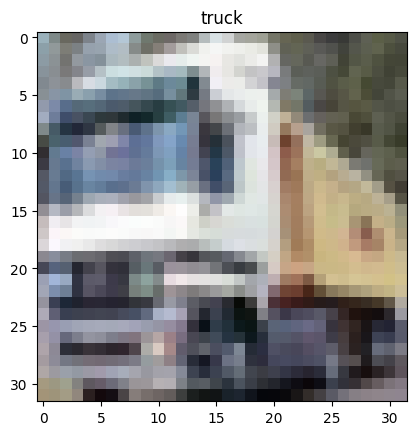

In [34]:
def show_image(X, label):
    red = np.reshape(X[:1024], (-1, 32))
    green = np.reshape(X[1024:2048], (-1, 32))
    blue = np.reshape(X[2048:], (-1, 32))

    rgb = np.dstack((red, green, blue))

    plt.title(label)
    plt.imshow(rgb)
        
show_image(X_train[1], class_names[np.argmax(y_train[1])])

In [ ]:
neural_net = NeuralNet((3*32**2, 1024, 256, 10), learning_rate=0.001, random_state = 42)

neural_net.layers[0].activation_method="ReLu"
neural_net.layers[0].weights = neural_net.layers[0].initialize("He")

neural_net.layers[1].activation_method="ReLu"
neural_net.layers[1].weights = neural_net.layers[1].initialize("He")

#neural_net.layers[2].activation_method="ReLu"
#neural_net.layers[2].weights = neural_net.layers[2].initialize("He")

neural_net.layers[-1].activation_method="softmax"
epochs = 50
losses, y_pred = neural_net.train(X_train,
                                  y_train,
                                  epochs,
                                  batch_size = 64,
                                  validate=(X_test[:2000], y_test[:2000]),
                                  categorical=True,
                                  lr_scheduling=True)

EPOCH: 1    LOSS: 0.193682    LOSS CHANGE: 0    TEST ACCURACY: 0.1035    TEST ACCURACY CHANGE 0.1035    TIME: 2.5e+02 s
EPOCH: 2    LOSS: 0.169128    LOSS CHANGE: -0.02455    TEST ACCURACY: 0.1625    TEST ACCURACY CHANGE 0.059    TIME: 5e+02 s
EPOCH: 3    LOSS: 0.160418    LOSS CHANGE: -0.00871    TEST ACCURACY: 0.2075    TEST ACCURACY CHANGE 0.045    TIME: 2.4e+02 s
EPOCH: 4    LOSS: 0.15576    LOSS CHANGE: -0.004658    TEST ACCURACY: 0.2015    TEST ACCURACY CHANGE -0.006    TIME: 2.3e+02 s
EPOCH: 5    LOSS: 0.151567    LOSS CHANGE: -0.004193    TEST ACCURACY: 0.1995    TEST ACCURACY CHANGE -0.002    TIME: 2.4e+02 s
EPOCH: 6    LOSS: 0.148143    LOSS CHANGE: -0.003425    TEST ACCURACY: 0.2595    TEST ACCURACY CHANGE 0.06    TIME: 2.4e+03 s
EPOCH: 7    LOSS: 0.145017    LOSS CHANGE: -0.003126    TEST ACCURACY: 0.259    TEST ACCURACY CHANGE -0.0005    TIME: 2.4e+02 s
EPOCH: 8    LOSS: 0.142365    LOSS CHANGE: -0.002652    TEST ACCURACY: 0.2605    TEST ACCURACY CHANGE 0.0015    TIME: 2.4

KeyboardInterrupt: 

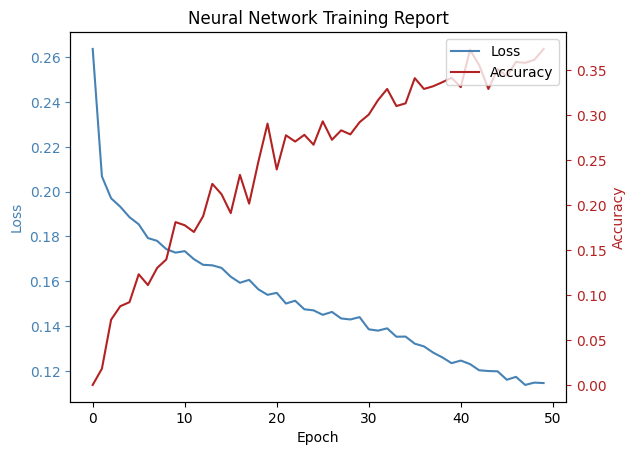

In [ ]:
graphics.plot_report(neural_net)

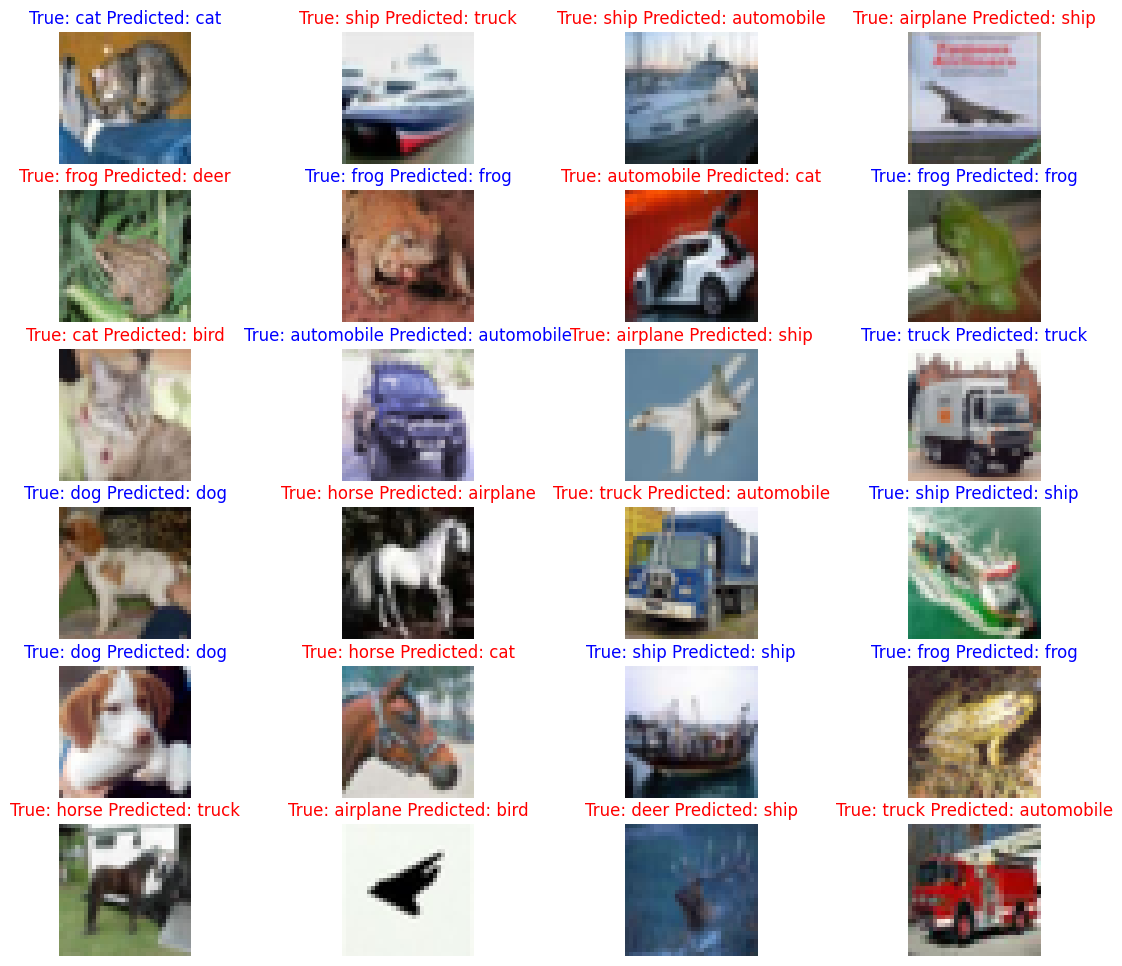

In [ ]:
y_pred_test = neural_net.predict(X_test)

def display_num(ax, X_total, i, true, pred):
    X = X_total[i]
    red = np.reshape(X[:1024], (-1, 32))
    green = np.reshape(X[1024:2048], (-1, 32))
    blue = np.reshape(X[2048:], (-1, 32))

    rgb = np.dstack((red, green, blue))

    ax.imshow(rgb)

    ax.set_title(f'True: {true} Predicted: {pred}', c="blue" if true == pred else "red")
    ax.axis('off') # Hide axis ticks

rows = 6
cols = 4

fig, axs = plt.subplots(rows, cols, figsize=(14, 12))

for i in range(rows*cols):
    current_row = i // cols
    current_col = i % cols
    
    # Select the correct subplot axis
    ax = axs[current_row, current_col]
    display_num(ax, X_test, i, class_names[np.argmax(y_test[i])], class_names[np.argmax(y_pred_test[i])])
plt.show()


In [ ]:
#neural_net.export("../models/CIFAR_10.h5")